In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url="https://docs.google.com/spreadsheets/d/1aDiNQMStFPyY7mJEgt2sIAApFrG2uE19/export?format=csv"
df=pd.read_csv(url)
df.head(10)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0
5,Amir Johnson,Boston Celtics,90,PF,29,06-Sep,240,NaN,12000000.0
6,Jordan Mickey,Boston Celtics,55,PF,21,06-Aug,235,LSU,1170960.0
7,Kelly Olynyk,Boston Celtics,41,C,25,7-0,238,Gonzaga,2165160.0
8,Terry Rozier,Boston Celtics,12,PG,22,06-Feb,190,Louisville,1824360.0
9,Marcus Smart,Boston Celtics,36,PG,22,06-Apr,220,Oklahoma State,3431040.0


Preprocessing

In [3]:
mode=df['College'].mode()[0]
print(mode)

Kentucky


In [4]:
df.fillna({"College":mode},inplace=True)
print(df.shape)
df.head(10)

(458, 9)


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,Kentucky,5000000.0
5,Amir Johnson,Boston Celtics,90,PF,29,06-Sep,240,Kentucky,12000000.0
6,Jordan Mickey,Boston Celtics,55,PF,21,06-Aug,235,LSU,1170960.0
7,Kelly Olynyk,Boston Celtics,41,C,25,7-0,238,Gonzaga,2165160.0
8,Terry Rozier,Boston Celtics,12,PG,22,06-Feb,190,Louisville,1824360.0
9,Marcus Smart,Boston Celtics,36,PG,22,06-Apr,220,Oklahoma State,3431040.0


In [5]:
df.dropna(inplace=True)
print(df.shape)

(447, 9)


In [6]:
df['Height']=np.random.randint(150,180,size=len(df))
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,175,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,166,235,Marquette,6796117.0
3,R.J. Hunter,Boston Celtics,28,SG,22,173,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,162,231,Kentucky,5000000.0
5,Amir Johnson,Boston Celtics,90,PF,29,179,240,Kentucky,12000000.0


In [7]:
df.drop_duplicates(inplace=True)
df.shape

(447, 9)

Analysis

In [169]:
x=df['Team'].value_counts()
x

,count
Team,
New Orleans Pelicans,19
Memphis Grizzlies,18
Utah Jazz,16
Milwaukee Bucks,16
New York Knicks,16
Boston Celtics,15
Los Angeles Clippers,15
Los Angeles Lakers,15
Phoenix Suns,15


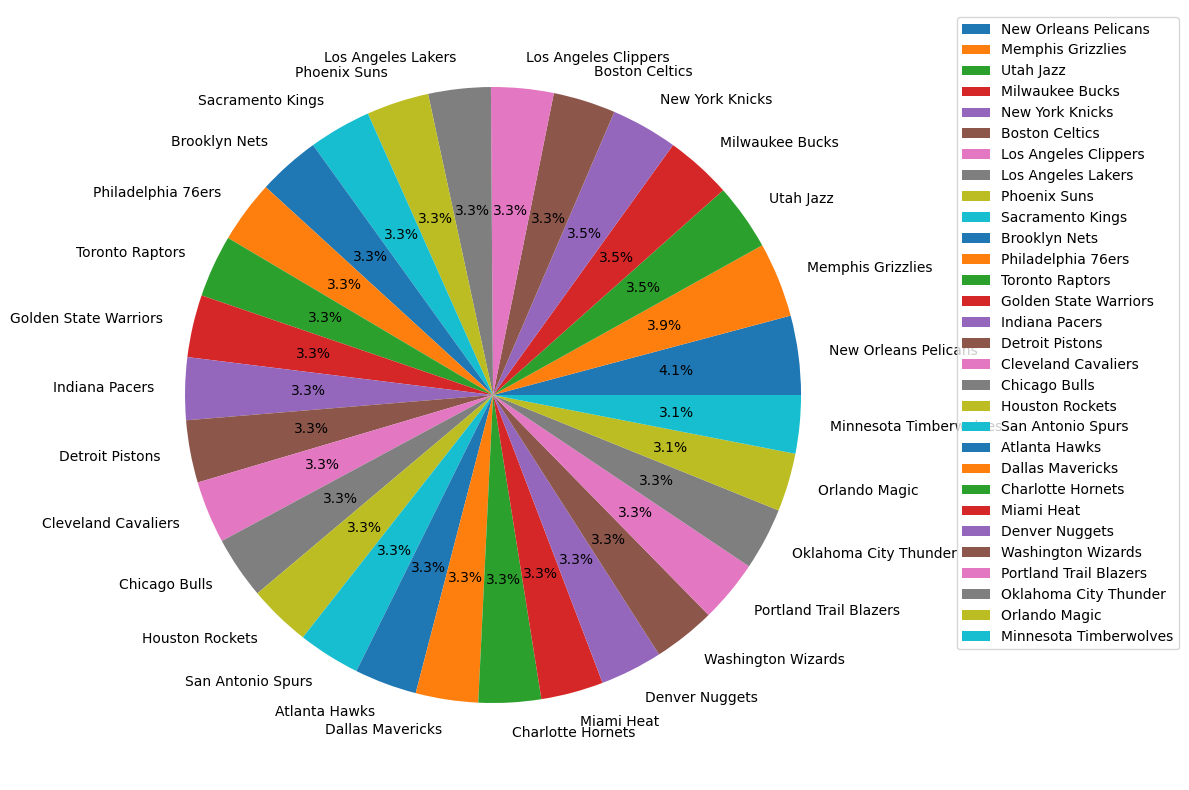

In [197]:
plt.figure(figsize=(10,10))
plt.pie(x,labels=x.index,data=x,autopct="%1.1f%%")
plt.legend(bbox_to_anchor=(1.4,1),loc='upper right')
plt.show()

INSIGHT : Team New Orleans Pelicans has relativly greater number of employees.In contrast Teams like Orlando Magic and Minnesota Timberwolves have comparitively less number of employees.

In [66]:
df['Team'].value_counts()
df.percentage=df['Team'].value_counts(normalize=True)*100
Team=pd.DataFrame(df.percentage)
print(Team)

                        proportion
Team                              
New Orleans Pelicans      4.148472
Memphis Grizzlies         3.930131
Utah Jazz                 3.493450
Milwaukee Bucks           3.493450
New York Knicks           3.493450
Boston Celtics            3.275109
Los Angeles Clippers      3.275109
Los Angeles Lakers        3.275109
Phoenix Suns              3.275109
Sacramento Kings          3.275109
Brooklyn Nets             3.275109
Philadelphia 76ers        3.275109
Toronto Raptors           3.275109
Golden State Warriors     3.275109
Indiana Pacers            3.275109
Detroit Pistons           3.275109
Cleveland Cavaliers       3.275109
Chicago Bulls             3.275109
Houston Rockets           3.275109
San Antonio Spurs         3.275109
Atlanta Hawks             3.275109
Dallas Mavericks          3.275109
Charlotte Hornets         3.275109
Miami Heat                3.275109
Denver Nuggets            3.275109
Washington Wizards        3.275109
Portland Trail Blaze

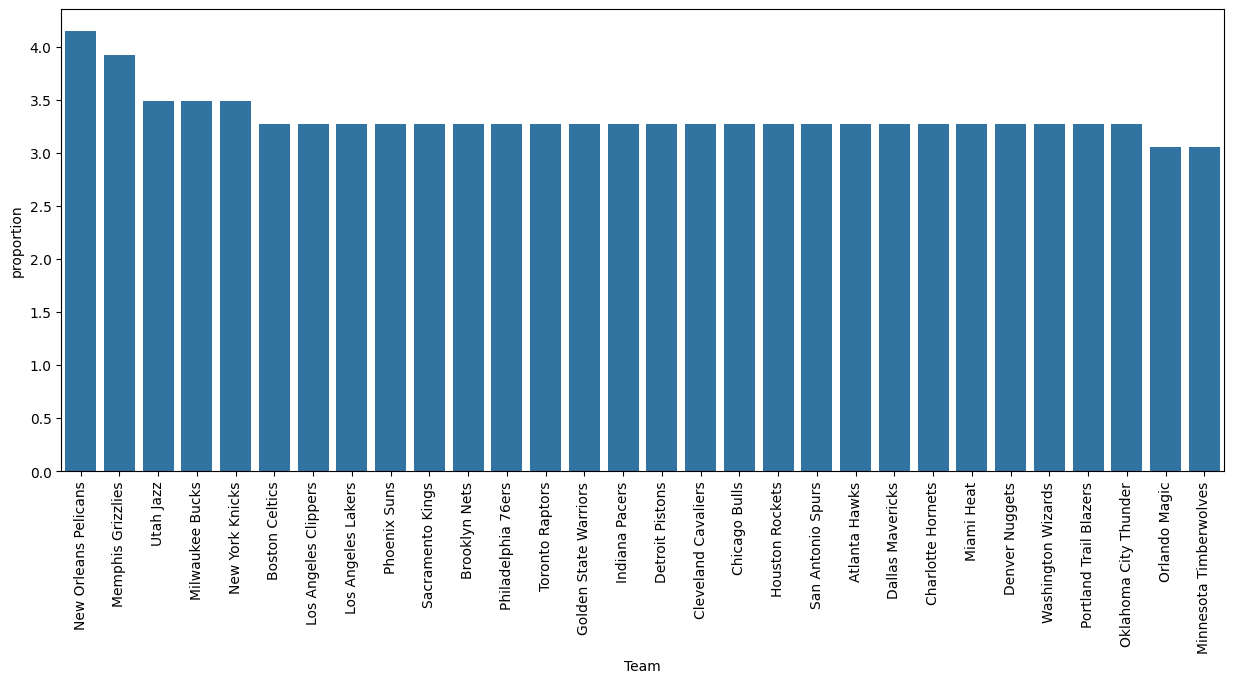

In [81]:
plt.figure(figsize=(15,6))
sns.barplot(x='Team',y='proportion',data=Team)
plt.xticks(rotation=90)
plt.show()

In [200]:
n=pd.DataFrame(df['Position'].value_counts())
n

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


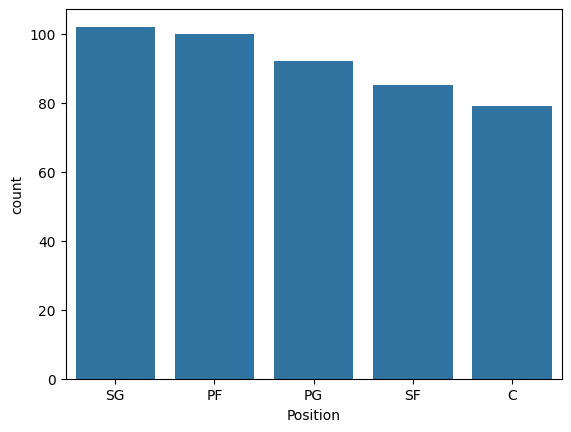

In [201]:
sns.barplot(x='Position',y='count',data=n)
plt.show()

INSIGHT : From the given data,most of the employees are in SG position and less number of employees in C position.Moreover,Half of the total employees and either in SG or PF position.Rest of the employees are in PG,SF and C.

In [202]:
m=pd.DataFrame(df.value_counts('Age').sort_index(ascending=False))
m



,count
Age,
40,3
39,2
38,4
37,4
36,10
35,9
34,10
33,14
32,13


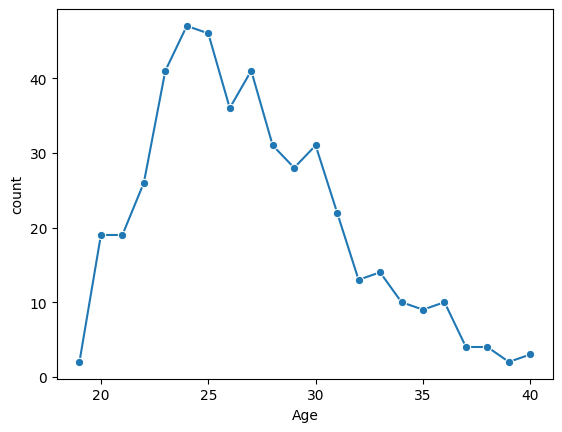

In [203]:
sns.lineplot(x='Age',y='count',data=m,marker='o')
plt.show()

INSIGHT : In this company employees are of age between 19 to 40.However,most of the employees fall between 20 to 35 age groups.Age 19 and 40 are the predominating ages in the given data.

In [204]:
h=pd.DataFrame(df.groupby('Team')['Salary'].sum().sort_values(ascending=False))
h

,Salary
Team,
Cleveland Cavaliers,106988689.0
Los Angeles Clippers,94854640.0
Oklahoma City Thunder,93765298.0
Golden State Warriors,88868997.0
Chicago Bulls,86783378.0
San Antonio Spurs,84442733.0
New Orleans Pelicans,82750774.0
Miami Heat,82515673.0
Charlotte Hornets,78340920.0


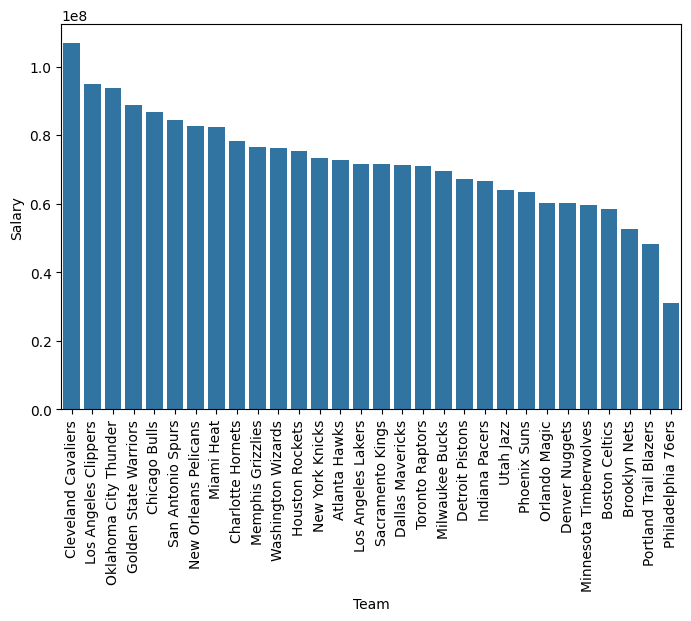

In [205]:
plt.figure(figsize=(8,5))
sns.barplot(x='Team',y='Salary',data=h)
plt.xticks(rotation=90)
plt.show()

INSIGHT : Cleveland Cavaliers is the high paid Team among the other Whereas Philadelphia 76ers Team paid the lowest.

In [206]:
s=pd.DataFrame(df.groupby('Position')['Salary'].sum().sort_values(ascending=False))
s

,Salary
Position,
C,466377332.0
PG,446848971.0
PF,442560850.0
SF,408020976.0
SG,396976258.0


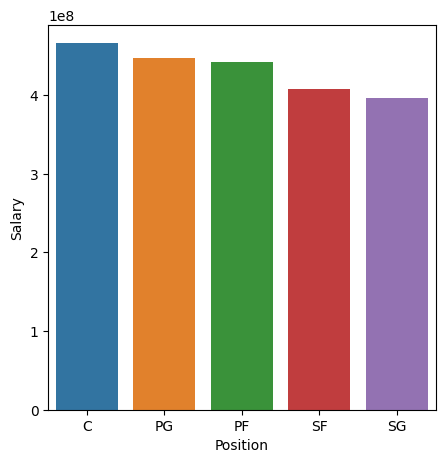

In [207]:
plt.figure(figsize=(5,5))
sns.barplot(x='Position',y='Salary',data=s,hue='Position')
plt.show()

INSIGHT : C is the high paid position,in contrast SG is the low paid.However there exsist no huge expenditure variation among each positions.

In [30]:
df[['Salary','Age']].corr()

,Salary,Age
Salary,1.000000,0.214009
Age,0.214009,1.000000


<Axes: >

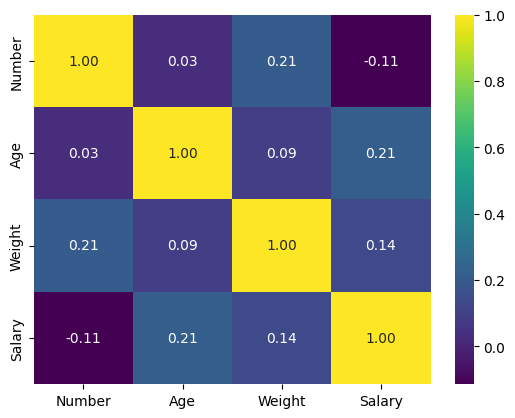

In [157]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='viridis',fmt='.2f')

INSIGHT : Salary and age is slightly correlated,but can't see a noticeable connection between these two column.